## Preprocessing search

Device : cuda
GPU    : Tesla P100-PCIE-16GB
Total recipes: 30
  A01_raw                             []
  B01_clahe                           ['clahe']
  B02_histogram_eq                    ['histogram_eq']
  B03_zscore                          ['zscore']
  B04_minmax                          ['minmax']
  B05_gamma_dark                      ['gamma_dark']
  B06_gamma_bright                    ['gamma_bright']
  C01_gaussian_blur                   ['gaussian_blur']
  C02_median_filter                   ['median_filter']
  C03_bilateral                       ['bilateral']
  D01_edge_enhance                    ['edge_enhance']
  E01_gaussian_clahe                  ['gaussian_blur', 'clahe']
  E02_median_clahe                    ['median_filter', 'clahe']
  E03_bilateral_clahe                 ['bilateral', 'clahe']
  E04_gaussian_zscore                 ['gaussian_blur', 'zscore']
  E05_median_zscore                   ['median_filter', 'zscore']
  E06_bilateral_zscore                ['bilate

100%|██████████| 548M/548M [00:03<00:00, 154MB/s]


    ep 01 | tr_acc 0.669 | va_acc 0.784 | va_roc 0.847 ✅
    ep 02 | tr_acc 0.827 | va_acc 0.802 | va_roc 0.863 ✅
    ep 03 | tr_acc 0.899 | va_acc 0.788 | va_roc 0.862
    ep 04 | tr_acc 0.952 | va_acc 0.798 | va_roc 0.857
    ep 05 | tr_acc 0.973 | va_acc 0.815 | va_roc 0.879 ✅
    ep 06 | tr_acc 0.984 | va_acc 0.787 | va_roc 0.864
    ep 07 | tr_acc 0.986 | va_acc 0.774 | va_roc 0.855
    ep 08 | tr_acc 0.988 | va_acc 0.809 | va_roc 0.877
    early stop @ ep 9
  val_su_roc=0.9160 | val_su_acc=0.8387 | test_su_roc=0.8908

[02/30] B01_clahe
  ops: clahe
    ep 01 | tr_acc 0.611 | va_acc 0.731 | va_roc 0.821 ✅
    ep 02 | tr_acc 0.801 | va_acc 0.717 | va_roc 0.826 ✅
    ep 03 | tr_acc 0.902 | va_acc 0.772 | va_roc 0.855 ✅
    ep 04 | tr_acc 0.954 | va_acc 0.767 | va_roc 0.841
    ep 05 | tr_acc 0.972 | va_acc 0.792 | va_roc 0.854
    ep 06 | tr_acc 0.974 | va_acc 0.789 | va_roc 0.852
    early stop @ ep 7
  val_su_roc=0.8908 | val_su_acc=0.8710 | test_su_roc=0.9454

[03/30] B02_histogr

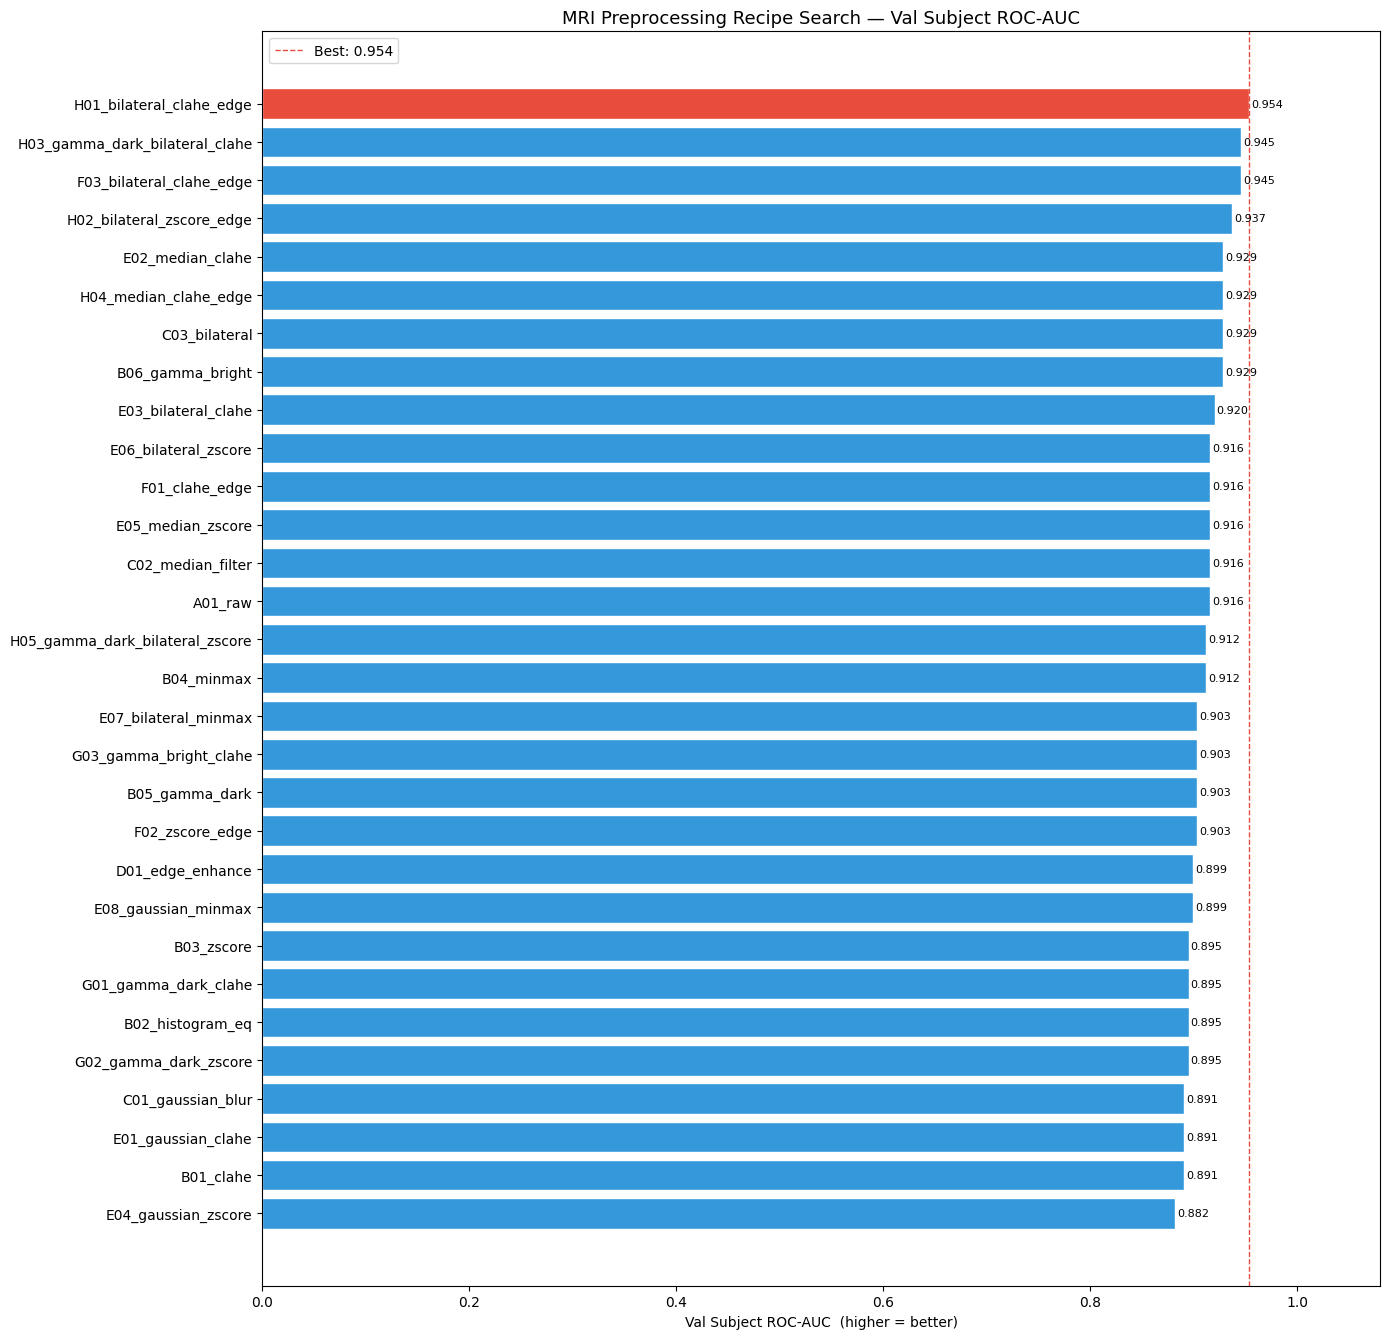

  Plot saved: /kaggle/working/preproc_results.png

  Best config saved: /kaggle/working/preproc_best_config.json
  Best recipe  : H01_bilateral_clahe_edge
  Best ops     : ['bilateral', 'clahe', 'edge_enhance']
  Val SuROC    : 0.9538
  Test SuROC   : 0.9076

HOW TO USE THE BEST RECIPE IN YOUR BASELINE

  1. Copy ALL_OPS dict and apply_recipe() function into baseline.py

  2. In your Dataset __getitem__, add before the transforms:

       img = apply_recipe(img, best_recipe_ops)

  3. That's it — the rest of the pipeline is unchanged.



In [1]:
# ==============================================================
# MRI Preprocessing Search
# Evaluates ~25 named preprocessing recipes on MRI 2D slices
# using the same VGG19 backbone as the baseline.
#
# Each recipe = an ordered list of preprocessing ops applied
# to each PNG slice before it reaches the model.
#
# Outputs:
#   preproc_results.csv      — all trials ranked by val ROC-AUC
#   preproc_results.png      — bar chart
#   preproc_best_config.json — best recipe config to copy into baseline
# ==============================================================

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps
from scipy.ndimage import median_filter as scipy_median
from skimage import exposure
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report

warnings.filterwarnings("ignore")

# ── reproducibility ───────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ==============================================================
# CONFIG  — adjust paths to match your environment
# ==============================================================
SPLITS_CSV = "/kaggle/input/datasets/jannatttt/mri-splits/mri_stage1_splits.csv"   # saved by baseline
OUT_DIR    = "/kaggle/working"

# The CSV was generated in a different Kaggle environment so the slice_path
# prefix has changed. Set these two variables to match your situation:
#   OLD_PATH_PREFIX — the prefix currently baked into the saved CSV
#   NEW_PATH_PREFIX — the correct prefix in your current environment
OLD_PATH_PREFIX = "/kaggle/input/datasets/adaisdiashdh/mri-pet-slices"
NEW_PATH_PREFIX = "/kaggle/input/mri-pet-slices"

CFG = dict(
    epochs      = 10,       # keep short — this is a search, not final training
    patience    = 4,        # early stopping
    batch_size  = 32,
    lr          = 5e-5,
    dense_units = 128,
    dropout     = 0.5,
    img_size    = 224,
    num_workers = 2,
)

LABEL_MAP = {"AD": 1, "CN": 0}
IDX2LABEL  = {0: "CN", 1: "AD"}

# ImageNet stats (fixed — same as baseline, never fit on data)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ==============================================================
# 1.  PREPROCESSING PRIMITIVES
# Each function: PIL Image (RGB) → PIL Image (RGB)
# ==============================================================

def op_identity(img: Image.Image) -> Image.Image:
    """No preprocessing — raw slice."""
    return img


def op_clahe(img: Image.Image) -> Image.Image:
    """
    CLAHE on the L channel of LAB colour space.
    Enhances local contrast without amplifying noise globally.
    Clip limit 2.0, tile 8×8 — standard radiological setting.
    """
    arr = np.array(img.convert("RGB"))
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)


def op_histogram_eq(img: Image.Image) -> Image.Image:
    """Global histogram equalization on grayscale, replicated to RGB."""
    gray = np.array(img.convert("L"))
    eq   = exposure.equalize_hist(gray)
    eq8  = (eq * 255).astype(np.uint8)
    rgb  = np.stack([eq8, eq8, eq8], axis=-1)
    return Image.fromarray(rgb)


def op_zscore(img: Image.Image) -> Image.Image:
    """
    Per-slice z-score: (pixel - mean) / std, then rescale to [0,255].
    Removes scanner-level intensity bias common across MRI machines.
    """
    arr  = np.array(img.convert("L")).astype(np.float32)
    mean, std = arr.mean(), arr.std()
    if std < 1e-6:
        std = 1.0
    norm = (arr - mean) / std
    # clip to ±3 sigma then rescale to [0,255]
    norm = np.clip(norm, -3, 3)
    norm = ((norm + 3) / 6 * 255).astype(np.uint8)
    rgb  = np.stack([norm, norm, norm], axis=-1)
    return Image.fromarray(rgb)


def op_minmax(img: Image.Image) -> Image.Image:
    """Per-slice min-max normalization to [0, 255]."""
    arr = np.array(img.convert("L")).astype(np.float32)
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-6:
        hi = lo + 1.0
    norm = ((arr - lo) / (hi - lo) * 255).astype(np.uint8)
    rgb  = np.stack([norm, norm, norm], axis=-1)
    return Image.fromarray(rgb)


def op_gaussian_blur(img: Image.Image) -> Image.Image:
    """
    Mild Gaussian blur (radius=1) to reduce high-frequency MRI noise.
    Preserves tissue boundaries while smoothing acquisition noise.
    """
    return img.filter(ImageFilter.GaussianBlur(radius=1))


def op_median_filter(img: Image.Image) -> Image.Image:
    """3×3 median filter — removes salt-and-pepper noise from MRI."""
    arr  = np.array(img.convert("L"))
    filt = scipy_median(arr, size=3).astype(np.uint8)
    rgb  = np.stack([filt, filt, filt], axis=-1)
    return Image.fromarray(rgb)


def op_gamma_dark(img: Image.Image) -> Image.Image:
    """Gamma = 0.75 — brightens dark slices, improves subcortical visibility."""
    arr  = np.array(img.convert("L")).astype(np.float32) / 255.0
    corr = np.power(arr, 0.75)
    out  = (corr * 255).astype(np.uint8)
    rgb  = np.stack([out, out, out], axis=-1)
    return Image.fromarray(rgb)


def op_gamma_bright(img: Image.Image) -> Image.Image:
    """Gamma = 1.5 — darkens bright background, emphasises tissue contrast."""
    arr  = np.array(img.convert("L")).astype(np.float32) / 255.0
    corr = np.power(arr, 1.5)
    out  = (corr * 255).astype(np.uint8)
    rgb  = np.stack([out, out, out], axis=-1)
    return Image.fromarray(rgb)





def op_edge_enhance(img: Image.Image) -> Image.Image:
    """
    Unsharp masking to enhance tissue boundary sharpness.
    Helps delineate hippocampal atrophy borders relevant for AD.
    """
    arr      = np.array(img.convert("L")).astype(np.float32)
    blurred  = cv2.GaussianBlur(arr, (0, 0), sigmaX=2)
    sharpened = np.clip(arr + 0.5 * (arr - blurred), 0, 255).astype(np.uint8)
    rgb = np.stack([sharpened, sharpened, sharpened], axis=-1)
    return Image.fromarray(rgb)


def op_bilateral(img: Image.Image) -> Image.Image:
    """
    Bilateral filter — smooths homogeneous regions while preserving edges.
    Better than Gaussian for MRI: keeps grey/white matter boundaries sharp.
    """
    arr  = np.array(img.convert("L"))
    filt = cv2.bilateralFilter(arr, d=9, sigmaColor=75, sigmaSpace=75)
    rgb  = np.stack([filt, filt, filt], axis=-1)
    return Image.fromarray(rgb)


# Registry of all available ops
ALL_OPS = {
    "identity":      op_identity,
    "clahe":         op_clahe,
    "histogram_eq":  op_histogram_eq,
    "zscore":        op_zscore,
    "minmax":        op_minmax,
    "gaussian_blur": op_gaussian_blur,
    "median_filter": op_median_filter,
    "gamma_dark":    op_gamma_dark,
    "gamma_bright":  op_gamma_bright,
    "edge_enhance":  op_edge_enhance,
    "bilateral":     op_bilateral,
}

# ==============================================================
# 2.  RECIPES
# Each recipe = ordered list of op names applied left → right.
# Rationale for each group is documented inline.
# ==============================================================

# Images are already skull-stripped — no skull_strip or center_crop ops needed.
# Ops available: clahe, histogram_eq, zscore, minmax, gamma_dark, gamma_bright,
#                gaussian_blur, median_filter, bilateral, edge_enhance
RECIPES = {
    # ── Group A: Baseline ──────────────────────────────────────
    "A01_raw":
        [],                             # no preprocessing — baseline to beat

    # ── Group B: Single normalization ─────────────────────────
    "B01_clahe":
        ["clahe"],
    "B02_histogram_eq":
        ["histogram_eq"],
    "B03_zscore":
        ["zscore"],
    "B04_minmax":
        ["minmax"],
    "B05_gamma_dark":
        ["gamma_dark"],                 # brighten dark slices
    "B06_gamma_bright":
        ["gamma_bright"],               # darken bright background

    # ── Group C: Single denoising ──────────────────────────────
    "C01_gaussian_blur":
        ["gaussian_blur"],
    "C02_median_filter":
        ["median_filter"],
    "C03_bilateral":
        ["bilateral"],                  # best edge-preserving smoother

    # ── Group D: Single sharpening ─────────────────────────────
    "D01_edge_enhance":
        ["edge_enhance"],               # sharpen hippocampal boundaries

    # ── Group E: Denoise → Normalize ──────────────────────────
    # Denoise first to avoid CLAHE/zscore amplifying noise
    "E01_gaussian_clahe":
        ["gaussian_blur", "clahe"],
    "E02_median_clahe":
        ["median_filter", "clahe"],
    "E03_bilateral_clahe":
        ["bilateral", "clahe"],         # best denoiser + best local contrast
    "E04_gaussian_zscore":
        ["gaussian_blur", "zscore"],
    "E05_median_zscore":
        ["median_filter", "zscore"],
    "E06_bilateral_zscore":
        ["bilateral", "zscore"],
    "E07_bilateral_minmax":
        ["bilateral", "minmax"],
    "E08_gaussian_minmax":
        ["gaussian_blur", "minmax"],

    # ── Group F: Normalize → Sharpen ──────────────────────────
    # Sharpen after normalizing so edge_enhance works on equalized contrast
    "F01_clahe_edge":
        ["clahe", "edge_enhance"],
    "F02_zscore_edge":
        ["zscore", "edge_enhance"],
    "F03_bilateral_clahe_edge":
        ["bilateral", "clahe", "edge_enhance"],

    # ── Group G: Gamma → Normalize ────────────────────────────
    # Gamma corrects global brightness before local contrast enhancement
    "G01_gamma_dark_clahe":
        ["gamma_dark", "clahe"],
    "G02_gamma_dark_zscore":
        ["gamma_dark", "zscore"],
    "G03_gamma_bright_clahe":
        ["gamma_bright", "clahe"],

    # ── Group H: Full 3-step pipelines ────────────────────────
    "H01_bilateral_clahe_edge":
        ["bilateral", "clahe", "edge_enhance"],
    "H02_bilateral_zscore_edge":
        ["bilateral", "zscore", "edge_enhance"],
    "H03_gamma_dark_bilateral_clahe":
        ["gamma_dark", "bilateral", "clahe"],
    "H04_median_clahe_edge":
        ["median_filter", "clahe", "edge_enhance"],
    "H05_gamma_dark_bilateral_zscore":
        ["gamma_dark", "bilateral", "zscore"],
}

print(f"Total recipes: {len(RECIPES)}")
for name, ops in RECIPES.items():
    print(f"  {name:<35} {ops}")

# ==============================================================
# 3.  DATASET
# ==============================================================

def apply_recipe(img: Image.Image, recipe: list) -> Image.Image:
    """Apply an ordered list of preprocessing op names to a PIL image."""
    for op_name in recipe:
        img = ALL_OPS[op_name](img)
    return img


class PreprocessDataset(Dataset):
    def __init__(self, df, recipe: list, augment: bool = False, img_size: int = 224):
        self.df      = df.reset_index(drop=True)
        self.recipe  = recipe
        self.img_size = img_size
        # Standard augmentation for training (same as baseline)
        if augment:
            self.post = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        else:
            self.post = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["slice_path"]).convert("RGB")
        img   = apply_recipe(img, self.recipe)
        # Ensure RGB after preprocessing (some ops return grayscale stacked)
        img   = img.convert("RGB")
        label = LABEL_MAP[row["group"]]
        tensor = self.post(img)
        return tensor, label, row["subject_id"]


def make_loaders(df, recipe, cfg):
    loaders = {}
    for split in ["train", "val", "test"]:
        sub = df[df["split"] == split]
        ds  = PreprocessDataset(
            sub, recipe,
            augment=(split == "train"),
            img_size=cfg["img_size"],
        )
        loaders[split] = DataLoader(
            ds,
            batch_size=cfg["batch_size"],
            shuffle=(split == "train"),
            num_workers=cfg["num_workers"],
            pin_memory=True,
        )
    return loaders

# ==============================================================
# 4.  MODEL  (same VGG19Extractor as baseline for fair comparison)
# ==============================================================

class VGG19Extractor(nn.Module):
    def __init__(self, dense_units=128, dropout=0.5, num_classes=2):
        super().__init__()
        base          = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.gap      = nn.AdaptiveAvgPool2d(1)
        self.dropout  = nn.Dropout(dropout)
        self.fc1      = nn.Linear(512, dense_units)
        self.fc2      = nn.Linear(dense_units, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ==============================================================
# 5.  TRAINING LOOP
# ==============================================================

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs, all_subjects = [], [], [], []
    for imgs, labels, subjects in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)[:, 1]
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_subjects.extend(subjects)
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels),
            np.array(all_probs), all_subjects)


def subject_agg(preds, labels, probs, subjects):
    """Mean-probability aggregation across slices → subject-level decision."""
    df = pd.DataFrame({"subject": subjects, "label": labels,
                        "pred": preds, "prob": probs})
    rows = []
    for subj, g in df.groupby("subject"):
        mean_prob  = g["prob"].mean()
        true_label = g["label"].iloc[0]
        rows.append({
            "subject":    subj,
            "true_label": true_label,
            "pred_label": int(mean_prob >= 0.5),
            "mean_prob":  mean_prob,
        })
    res = pd.DataFrame(rows)
    acc = (res["true_label"] == res["pred_label"]).mean()
    fpr, tpr, _ = roc_curve(res["true_label"], res["mean_prob"])
    su_roc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(res["true_label"], res["mean_prob"])
    su_pr = auc(rec, prec)
    return acc, su_roc, su_pr


def run_trial(recipe_name, recipe_ops, df, cfg, tmp_path):
    """Train one recipe for cfg['epochs'] epochs with early stopping.
    Returns a dict of metrics."""
    loaders = make_loaders(df, recipe_ops, cfg)
    model   = VGG19Extractor(cfg["dense_units"], cfg["dropout"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])

    best_val_roc = 0.0
    no_improve   = 0

    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_acc = train_epoch(model, loaders["train"], optimizer, criterion)
        va_loss, va_acc, va_preds, va_lbls, va_probs, va_subjs = \
            eval_epoch(model, loaders["val"], criterion)

        # Compute val ROC-AUC for model selection (more stable than acc)
        fpr, tpr, _ = roc_curve(va_lbls, va_probs)
        va_roc = auc(fpr, tpr)

        if va_roc > best_val_roc:
            best_val_roc = va_roc
            no_improve   = 0
            torch.save(model.state_dict(), tmp_path)
        else:
            no_improve += 1
            if no_improve >= cfg["patience"]:
                print(f"    early stop @ ep {epoch}")
                break

        print(f"    ep {epoch:02d} | tr_acc {tr_acc:.3f} | "
              f"va_acc {va_acc:.3f} | va_roc {va_roc:.3f}"
              + (" ✅" if no_improve == 0 else ""))

    # ── Evaluate best checkpoint on val (for comparison table) ──
    model.load_state_dict(torch.load(tmp_path, map_location=DEVICE))
    _, sl_acc, sl_preds, sl_lbls, sl_probs, sl_subjs = \
        eval_epoch(model, loaders["val"], criterion)

    fpr, tpr, _ = roc_curve(sl_lbls, sl_probs)
    sl_roc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(sl_lbls, sl_probs)
    sl_pr  = auc(rec, prec)
    su_acc, su_roc, su_pr = subject_agg(sl_preds, sl_lbls, sl_probs, sl_subjs)

    # ── Also evaluate on test for final reporting ────────────────
    _, tsl_acc, tsl_preds, tsl_lbls, tsl_probs, tsl_subjs = \
        eval_epoch(model, loaders["test"], criterion)
    fpr, tpr, _ = roc_curve(tsl_lbls, tsl_probs)
    tsl_roc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(tsl_lbls, tsl_probs)
    tsl_pr  = auc(rec, prec)
    tsu_acc, tsu_roc, tsu_pr = subject_agg(tsl_preds, tsl_lbls, tsl_probs, tsl_subjs)

    return {
        "recipe":           recipe_name,
        "ops":              " → ".join(recipe_ops) if recipe_ops else "(none)",
        # Validation metrics (used for ranking)
        "val_sl_acc":       round(sl_acc,  4),
        "val_su_acc":       round(su_acc,  4),
        "val_sl_roc":       round(sl_roc,  4),
        "val_su_roc":       round(su_roc,  4),
        "val_sl_pr":        round(sl_pr,   4),
        "val_su_pr":        round(su_pr,   4),
        # Test metrics (reported but NOT used for ranking)
        "test_sl_acc":      round(tsl_acc,  4),
        "test_su_acc":      round(tsu_acc,  4),
        "test_sl_roc":      round(tsl_roc,  4),
        "test_su_roc":      round(tsu_roc,  4),
        "test_sl_pr":       round(tsl_pr,   4),
        "test_su_pr":       round(tsu_pr,   4),
    }

# ==============================================================
# 6.  RESULTS & PLOTS
# ==============================================================

def plot_results(results_df, out_dir):
    """Bar chart of val subject ROC-AUC for all recipes."""
    df = results_df.sort_values("val_su_roc", ascending=True)
    colors = ["#e74c3c" if r == df["val_su_roc"].max() else "#3498db"
              for r in df["val_su_roc"]]

    fig, ax = plt.subplots(figsize=(14, max(6, len(df) * 0.45)))
    bars = ax.barh(df["recipe"], df["val_su_roc"], color=colors, edgecolor="white")
    ax.set_xlabel("Val Subject ROC-AUC  (higher = better)")
    ax.set_title("MRI Preprocessing Recipe Search — Val Subject ROC-AUC", fontsize=13)
    ax.axvline(df["val_su_roc"].iloc[-1], color="#e74c3c", linestyle="--",
               linewidth=1, label=f"Best: {df['val_su_roc'].max():.3f}")

    # Annotate bars
    for bar, val in zip(bars, df["val_su_roc"]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", ha="left", fontsize=8)

    ax.legend(); ax.set_xlim(0, 1.08)
    plt.tight_layout()
    path = os.path.join(out_dir, "preproc_results.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Plot saved: {path}")


def print_leaderboard(results_df):
    """Print a clean ranked table to stdout."""
    df = results_df.sort_values("val_su_roc", ascending=False).reset_index(drop=True)
    print("\n" + "=" * 95)
    print("PREPROCESSING SEARCH — LEADERBOARD  (ranked by val subject ROC-AUC)")
    print("=" * 95)
    header = (f"{'Rank':<5} {'Recipe':<35} {'Ops':<35} "
              f"{'Val SuROC':>9} {'Val SuAcc':>9} {'Test SuROC':>10}")
    print(header)
    print("-" * 95)
    for i, row in df.iterrows():
        marker = " ◀ BEST" if i == 0 else ""
        ops_str = row["ops"][:34] if len(row["ops"]) > 34 else row["ops"]
        print(f"{i+1:<5} {row['recipe']:<35} {ops_str:<35} "
              f"{row['val_su_roc']:>9.4f} {row['val_su_acc']:>9.4f} "
              f"{row['test_su_roc']:>10.4f}{marker}")
    print("=" * 95)
    return df

# ==============================================================
# 7.  MAIN
# ==============================================================

def main():
    # ── Load split CSV produced by baseline ───────────────────
    print(f"\nLoading splits from: {SPLITS_CSV}")
    df = pd.read_csv(SPLITS_CSV)

    # ── Fix stale path prefix in slice_path column ──────────────
    # Replace OLD_PATH_PREFIX with NEW_PATH_PREFIX across all rows.
    if OLD_PATH_PREFIX != NEW_PATH_PREFIX:
        before = df["slice_path"].iloc[0]
        df["slice_path"] = df["slice_path"].str.replace(
            OLD_PATH_PREFIX, NEW_PATH_PREFIX, regex=False)
        after = df["slice_path"].iloc[0]
        print(f"  Path prefix fix applied:")
        print(f"    before: {before}")
        print(f"    after : {after}")
    else:
        print("  Paths unchanged (OLD_PATH_PREFIX == NEW_PATH_PREFIX)")

    print(f"  {len(df)} slice rows | "
          f"{df['subject_id'].nunique()} subjects | "
          f"splits: {df['split'].value_counts().to_dict()}")

    # Quick sanity: verify a sample of paths actually exist
    missing = [p for p in df["slice_path"].head(20) if not os.path.exists(p)]
    if missing:
        print(f"  ❌ WARNING: {len(missing)}/20 sample paths not found.")
        print(f"     Example missing: {missing[0]}")
        print(f"     Check OLD_PATH_PREFIX / NEW_PATH_PREFIX in CONFIG.")
    else:
        print(f"  ✅ Path check passed — all 20 sample paths exist")

    tmp_path = os.path.join(OUT_DIR, "_preproc_tmp.pth")
    all_results = []

    print(f"\nRunning {len(RECIPES)} recipes — {CFG['epochs']} epochs each\n")
    print("=" * 60)

    for idx, (recipe_name, recipe_ops) in enumerate(RECIPES.items()):
        ops_str = " → ".join(recipe_ops) if recipe_ops else "(none)"
        print(f"\n[{idx+1:02d}/{len(RECIPES)}] {recipe_name}")
        print(f"  ops: {ops_str}")

        try:
            result = run_trial(recipe_name, recipe_ops, df, CFG, tmp_path)
            all_results.append(result)
            print(f"  val_su_roc={result['val_su_roc']:.4f} | "
                  f"val_su_acc={result['val_su_acc']:.4f} | "
                  f"test_su_roc={result['test_su_roc']:.4f}")
        except Exception as e:
            print(f"  ❌ FAILED: {e}")
            all_results.append({"recipe": recipe_name, "ops": ops_str,
                                  "val_su_roc": 0.0, "error": str(e)})

    # ── Results ───────────────────────────────────────────────
    results_df = pd.DataFrame(all_results).fillna(0)

    # Rank by val subject ROC-AUC
    ranked_df = print_leaderboard(results_df)

    # Save CSV
    csv_path = os.path.join(OUT_DIR, "preproc_results.csv")
    ranked_df.to_csv(csv_path, index=False)
    print(f"\n  Full results saved: {csv_path}")

    # Plot
    plot_results(ranked_df, OUT_DIR)

    # ── Save best recipe as JSON ───────────────────────────────
    best = ranked_df.iloc[0]
    best_recipe_ops = RECIPES[best["recipe"]]
    best_config = {
        "best_recipe_name": best["recipe"],
        "best_recipe_ops":  best_recipe_ops,
        "val_su_roc":       best["val_su_roc"],
        "val_su_acc":       best["val_su_acc"],
        "test_su_roc":      best["test_su_roc"],
        "test_su_acc":      best["test_su_acc"],
        "note": (
            "To use in baseline: pass this ops list to apply_recipe() "
            "inside your Dataset __getitem__ before the torchvision transforms."
        ),
    }
    json_path = os.path.join(OUT_DIR, "preproc_best_config.json")
    with open(json_path, "w") as f:
        json.dump(best_config, f, indent=2)
    print(f"\n  Best config saved: {json_path}")
    print(f"  Best recipe  : {best['recipe']}")
    print(f"  Best ops     : {best_recipe_ops}")
    print(f"  Val SuROC    : {best['val_su_roc']:.4f}")
    print(f"  Test SuROC   : {best['test_su_roc']:.4f}")

    # ── How to apply the best recipe in baseline ───────────────
    print("\n" + "=" * 60)
    print("HOW TO USE THE BEST RECIPE IN YOUR BASELINE")
    print("=" * 60)
    print("""
  1. Copy ALL_OPS dict and apply_recipe() function into baseline.py

  2. In your Dataset __getitem__, add before the transforms:

       img = apply_recipe(img, best_recipe_ops)

  3. That's it — the rest of the pipeline is unchanged.
""")

    # Cleanup temp checkpoint
    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    return ranked_df


if __name__ == "__main__":
    results = main()